##  Step 1: Load Cleaned Data + Stage Labels (FD002)


### Step 1A – Load FD002 Clustered Data

We begin Phase 4 (Regression) by loading the FD002 dataset enriched with cluster labels from Phase 2. This file (`corrected_clustered_train_FD002.csv`) contains per-cycle sensor readings, operational settings, and their mapped `final_stage` degradation labels (Stage 0–4). These are required to compute our regression target: **cycles remaining until next degradation stage**.


In [24]:
import pandas as pd
import numpy as np
import os

# Set base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
data_file = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD002.csv')

# Load the data
df = pd.read_csv(data_file)
print("Loaded data:")
print(df.head())


Loaded data:
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_1  sensor_2  \
0     1     1       34.9983        0.8400         100.0  0.060269  0.181576   
1     1     2       41.9982        0.8408         100.0  0.000000  0.131847   
2     1     3       24.9988        0.6218          60.0  0.238089  0.016332   
3     1     4       42.0077        0.8416         100.0  0.000000  0.128269   
4     1     5       25.0005        0.6203          60.0  0.238089  0.014130   

   sensor_3  sensor_4  sensor_5  ...  sensor_21  kmeans_cluster  \
0  0.311201  0.273095  0.146592  ...   0.159082               0   
1  0.296600  0.245535  0.000000  ...   0.014562               0   
2  0.035297  0.056997  0.293184  ...   0.151414               2   
3  0.298795  0.246979  0.000000  ...   0.026144               0   
4  0.037871  0.058152  0.293184  ...   0.143240               2   

   agglo_cluster  kmeans_stage  agglo_stage     pca_1     pca_2     tsne_1  \
0              0       Stage 0 

### Step 1B – Sort Data by Engine and Time

Sorting by `unit` and `time` ensures that cycles are in chronological order for each engine. This is critical for correctly calculating when degradation stages change in the next step.


In [25]:
df = df.sort_values(by=['unit', 'time']).reset_index(drop=True)

### Step 1C – Initialize `cycles_to_next_stage` Column

We create a placeholder column called `cycles_to_next_stage` and fill it with `NaN`. We will compute the actual values in Step 1D by detecting transitions between stages.

In [26]:
df['cycles_to_next_stage'] = np.nan

### Step 1D – Compute `cycles_to_next_stage`

For each engine unit, we iterate through the cycles and track when the `final_stage` label changes. When a change is detected, we calculate the difference in cycle count to get the **time (in cycles) to the next degradation stage**.

This label becomes our regression target.

In [27]:
engine_ids = df['unit'].unique()

for engine_id in engine_ids:
    engine_df = df[df['unit'] == engine_id]
    indices = engine_df.index.tolist()
    stages = engine_df['final_stage'].tolist()
    times = engine_df['time'].tolist()

    for i in range(len(indices)):
        current_stage = stages[i]
        current_time = times[i]

        found = False
        for j in range(i + 1, len(indices)):
            if stages[j] != current_stage:
                next_time = times[j]
                df.loc[indices[i], 'cycles_to_next_stage'] = next_time - current_time
                found = True
                break

        if not found:
            df.loc[indices[i], 'cycles_to_next_stage'] = np.nan  # No stage change after this point


### Step 1E – Preview Sample `cycles_to_next_stage`

This table shows how the computed target values look. For example, if the current row is Stage 2 and the next stage (Stage 3) occurs in 30 cycles, the label is 30. This confirms that our target labels reflect real-world degradation timelines.

In [28]:
print("\nPreview of computed cycles_to_next_stage:")
print(df[['unit', 'time', 'final_stage', 'cycles_to_next_stage']].head(20))


Preview of computed cycles_to_next_stage:
    unit  time final_stage  cycles_to_next_stage
0      1     1     Stage 0                   2.0
1      1     2     Stage 0                   1.0
2      1     3     Stage 2                   1.0
3      1     4     Stage 0                   1.0
4      1     5     Stage 2                   2.0
5      1     6     Stage 2                   1.0
6      1     7     Stage 0                   1.0
7      1     8     Stage 4                   1.0
8      1     9     Stage 0                   3.0
9      1    10     Stage 0                   2.0
10     1    11     Stage 0                   1.0
11     1    12     Stage 1                   1.0
12     1    13     Stage 4                   1.0
13     1    14     Stage 0                   1.0
14     1    15     Stage 3                   1.0
15     1    16     Stage 0                   1.0
16     1    17     Stage 2                   1.0
17     1    18     Stage 0                   2.0
18     1    19     Stage 0

### Step 1F – Save Dataset and Perform Sanity Checks

We export this enriched data to `regression_train_FD002.csv`, which will be used in the regression modeling steps. We also check:
- Total number of rows
- Number of rows with missing target labels (`NaN`) — typically the last cycles where no further degradation stage occurs


In [29]:
output_path = os.path.join(BASE_DIR, 'data', 'regression_train_FD002.csv')
df.to_csv(output_path, index=False)
print(f"\nSaved enriched dataset with regression labels to: {output_path}")

# Sanity check
print("Total rows:", len(df))
print("Missing target labels (NaN):", df['cycles_to_next_stage'].isna().sum())



Saved enriched dataset with regression labels to: c:\Users\pandr\hybrid-predictive-maintenance\data\regression_train_FD002.csv
Total rows: 53759
Missing target labels (NaN): 376


---
# Step 2 – Feature Selection + Train-Test Split (FD002)

### Step 2A: Load Regression-Labeled FD002 Data

We begin by loading the enriched FD002 dataset that contains the newly created regression target: `cycles_to_next_stage`.  
This target represents the number of cycles remaining until the next degradation stage for each engine time-step.

As a standard sanity step, we drop any rows where this label is missing — typically these are the final readings of engines where no future stage transition exists.

This cleaned dataset will be used for feature selection and train-test splitting.


In [30]:
import pandas as pd

# Load regression-labeled dataset
df = pd.read_csv("../../data/regression_train_FD002.csv")

# Drop rows where cycles_to_next_stage is NaN (usually end-of-life points)
df = df.dropna(subset=["cycles_to_next_stage"]).reset_index(drop=True)

print(f"Dataset shape after dropping NaNs: {df.shape}")
df.head()


Dataset shape after dropping NaNs: (53383, 36)


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2,final_stage,cycles_to_next_stage
0,1,1,34.9983,0.8400,100.0,0.060269,0.181576,0.311201,0.273095,0.146592,...,0,0,Stage 0,Stage 0,-0.715411,0.451609,13.341684,-29.292095,Stage 0,2.0
1,1,2,41.9982,0.8408,100.0,0.000000,0.131847,0.296600,0.245535,0.000000,...,0,0,Stage 0,Stage 0,-0.974469,0.611144,-33.447270,14.554188,Stage 0,1.0
2,1,3,24.9988,0.6218,60.0,0.238089,0.016332,0.035297,0.056997,0.293184,...,2,2,Stage 2,Stage 2,-1.731143,-1.245858,-27.904293,-51.840656,Stage 2,1.0
3,1,4,42.0077,0.8416,100.0,0.000000,0.128269,0.298795,0.246979,0.000000,...,0,0,Stage 0,Stage 0,-0.975352,0.605181,-37.188313,9.020105,Stage 0,1.0
4,1,5,25.0005,0.6203,60.0,0.238089,0.014130,0.037871,0.058152,0.293184,...,2,2,Stage 2,Stage 2,-1.732085,-1.244550,-25.205564,-50.224857,Stage 2,2.0


### Step 2B: Define Features and Target

In [31]:
# Final sensor set after Phase 2.5 for FD002
features = ['sensor_1', 'sensor_12']
target = 'cycles_to_next_stage'

X = df[features]
y = df[target]

print("Input shape:", X.shape)
print("Target shape:", y.shape)
X.head()


Input shape: (53383, 2)
Target shape: (53383,)


,sensor_1,sensor_12
0,0.060269,0.136817
1,0.000000,0.003297
2,0.238089,0.089030
3,0.000000,0.004058
4,0.238089,0.089258


### Step 2C: Stratified Train-Test Split by Engine Unit

In [32]:
# Step 2C: Stratified Train-Test Split by Engine Unit
from sklearn.model_selection import train_test_split

# Unique engine units
units = df['unit'].unique()

# Stratified engine-based split
train_units, test_units = train_test_split(units, test_size=0.2, random_state=42)

# Create split datasets
train_df = df[df['unit'].isin(train_units)].reset_index(drop=True)
test_df = df[df['unit'].isin(test_units)].reset_index(drop=True)

# Final inputs and targets
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (43159, 2), Test shape: (10224, 2)


### Step 2D: Sanity Check – Engine Coverage

In [33]:
# Step 2D: Sanity Check – Engine Coverage
print("Train engine count:", train_df['unit'].nunique())
print("Test engine count:", test_df['unit'].nunique())


Train engine count: 208
Test engine count: 52


---
# Step 3 – Random Forest Regressor with Full Evaluation (FD002)

### Step 3A – Import Required Libraries (FD002)
In this step, we import all the essential libraries required to train, evaluate, and visualize a Random Forest Regressor. This includes the regressor itself from `sklearn`, evaluation metrics, plotting libraries, and joblib for saving the trained model.


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

### Step 3B – Initialize and Train Random Forest Regressor (FD002)
We initialize the Random Forest model with controlled hyperparameters to prevent overfitting. The model is trained on the training set (`X_train`, `y_train`) using two selected sensors from Phase 2.5.


In [35]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_regressor.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

### Step 3C – Predict and Evaluate the Random Forest Model (FD002)
We predict the test set using the trained model and compute the RMSE, MAE, and R² score to understand the model's performance.  
- **RMSE (Root Mean Square Error)** penalizes large errors more heavily.  
- **MAE (Mean Absolute Error)** gives the average magnitude of errors.  
- **R² Score** indicates how much of the variation in the target is explained by the model.


In [36]:
y_pred_rf = rf_regressor.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Evaluation Metrics (FD002):")
print(f" RMSE: {rmse_rf:.2f}")
print(f" MAE : {mae_rf:.2f}")
print(f" R²  : {r2_rf:.4f}")

Random Forest Evaluation Metrics (FD002):
 RMSE: 0.76
 MAE : 0.51
 R²  : 0.0728


#### Step 3C-1 – Cross-Validation Evaluation

In [37]:
# Step 3C-1 – Cross-Validation Evaluation 
from sklearn.model_selection import cross_val_score, KFold

# Setup 5-fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation metrics
rmse_scores = -cross_val_score(rf_regressor, X_train, y_train, scoring='neg_root_mean_squared_error', cv=cv)
mae_scores = -cross_val_score(rf_regressor, X_train, y_train, scoring='neg_mean_absolute_error', cv=cv)
r2_scores = cross_val_score(rf_regressor, X_train, y_train, scoring='r2', cv=cv)

print("\nCross-Validation Evaluation (Random Forest – FD002):")
print(f"CV RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
print(f"CV MAE : {mae_scores.mean():.2f} ± {mae_scores.std():.2f}")
print(f"CV R²  : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")



Cross-Validation Evaluation (Random Forest – FD002):
CV RMSE: 0.76 ± 0.02
CV MAE : 0.51 ± 0.01
CV R²  : 0.0766 ± 0.0075


### Step 3D – Plot: Predicted vs Actual (FD002)
This scatter plot compares the predicted values from the Random Forest model to the actual values of `cycles_to_next_stage`.  
- The **red dashed line** indicates the ideal prediction (perfect fit).  
- Points closer to the red line mean better prediction accuracy.  
- This visual check helps assess bias and variance in the predictions.


Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_pred_vs_actual_fd002.png


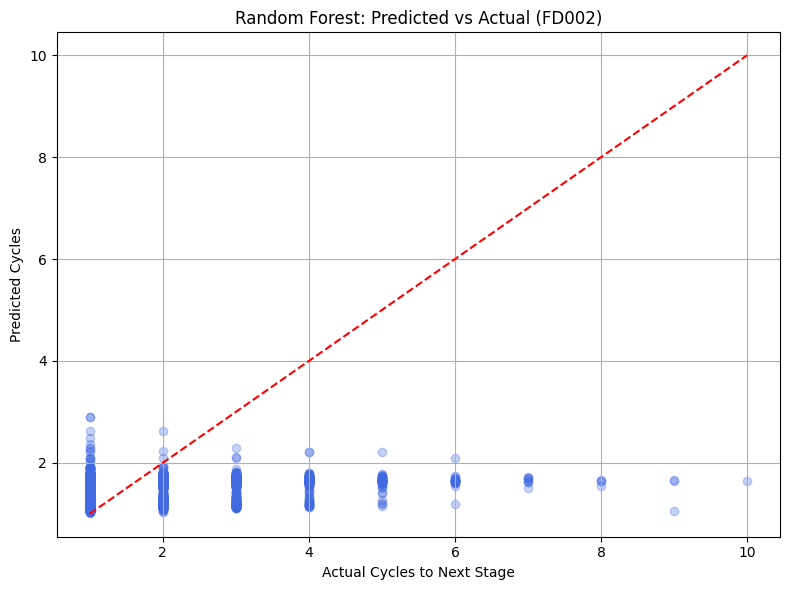

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("Random Forest: Predicted vs Actual (FD002)")
plt.grid(True)
plt.tight_layout()

# Save figure
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_pred_vs_actual_fd002.png'))
plt.savefig(fig_path)
print(f"Saved prediction plot to: {fig_path}")
plt.show()


### Step 3E – Save the Trained Model (FD002)
We save the trained Random Forest Regressor using `joblib`.  
This model can later be loaded for inference or ensemble without retraining.


In [39]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'rf_regressor_fd002.pkl'))
joblib.dump(rf_regressor, model_path)
print(f"Model saved to: {model_path}")


Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\rf_regressor_fd002.pkl


### Step 3F – Plot: Feature Importances (FD002)
This horizontal bar chart shows the importance of each selected sensor feature (`sensor_1`, `sensor_12`) as calculated by the Random Forest model.  
Higher importance means the feature contributed more to the model’s predictions.


Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_feature_importance_fd002.png


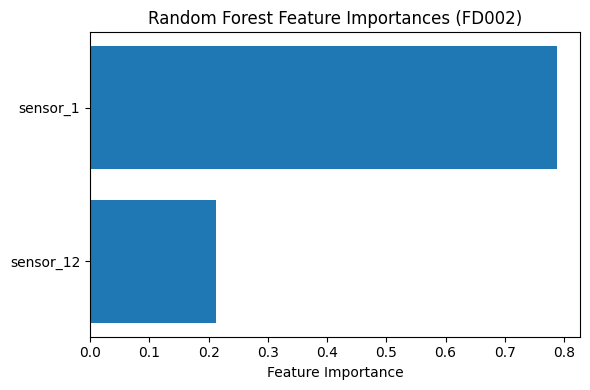

In [40]:
importances = rf_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(X_train.columns)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(X_train.columns)), [X_train.columns[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (FD002)")
plt.tight_layout()

# Save figure
feat_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_feature_importance_fd002.png'))
plt.savefig(feat_imp_path)
print(f"Feature importance plot saved to: {feat_imp_path}")
plt.show()

---
# Step 4 – Ridge Regression (FD002)

### Step 4A – Import Required Libraries (FD002)
In this step, we import the required components for Ridge Regression.
Ridge is a linear regression model with L2 regularization, which helps reduce overfitting and stabilizes the solution when multicollinearity exists between features.

In [41]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

### Step 4B – Initialize and Train Ridge Regression (FD002)
We now initialize the Ridge regression model with alpha=1.0 (regularization strength) and train it using the selected features from Phase 2.5 (sensor_1, sensor_12) on the training set.

In [42]:
ridge_regressor = Ridge(alpha=1.0, random_state=42)
ridge_regressor.fit(X_train, y_train)

Ridge(random_state=42)

### Step 4C – Predict and Evaluate Ridge Model (FD002)
We predict on the test set and evaluate performance using three key regression metrics:

RMSE (Root Mean Square Error): Penalizes large errors.

MAE (Mean Absolute Error): Average absolute error.

R² Score: Measures the proportion of variance explained by the model.

In [43]:
y_pred_ridge = ridge_regressor.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Evaluation Metrics (FD002):")
print(f" RMSE: {rmse_ridge:.2f}")
print(f" MAE : {mae_ridge:.2f}")
print(f" R²  : {r2_ridge:.4f}")

Ridge Regression Evaluation Metrics (FD002):
 RMSE: 0.77
 MAE : 0.52
 R²  : 0.0711


#### Step 4C-1 Cross Validation Evaluation

In [44]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

ridge_pipeline = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))

cv_rmse_ridge = -cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_ridge = -cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_ridge = cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='r2')


print("\nCross-Validation Evaluation (Ridge Regression – FD002):")
print(f"CV RMSE: {cv_rmse_ridge.mean():.2f} ± {cv_rmse_ridge.std():.2f}")
print(f"CV MAE : {cv_mae_ridge.mean():.2f} ± {cv_mae_ridge.std():.2f}")
print(f"CV R²  : {cv_r2_ridge.mean():.4f} ± {cv_r2_ridge.std():.4f}")



Cross-Validation Evaluation (Ridge Regression – FD002):
CV RMSE: 0.76 ± 0.03
CV MAE : 0.52 ± 0.01
CV R²  : 0.0708 ± 0.0036


### Step 4D – Plot: Predicted vs Actual (FD002)
This scatter plot compares predicted values from the Ridge model with the actual test targets (cycles_to_next_stage).

Red dashed line (y = x) shows ideal predictions.

Points near the line = good predictions.

Spread away from line = more error or underfitting.

Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_pred_vs_actual_fd002.png


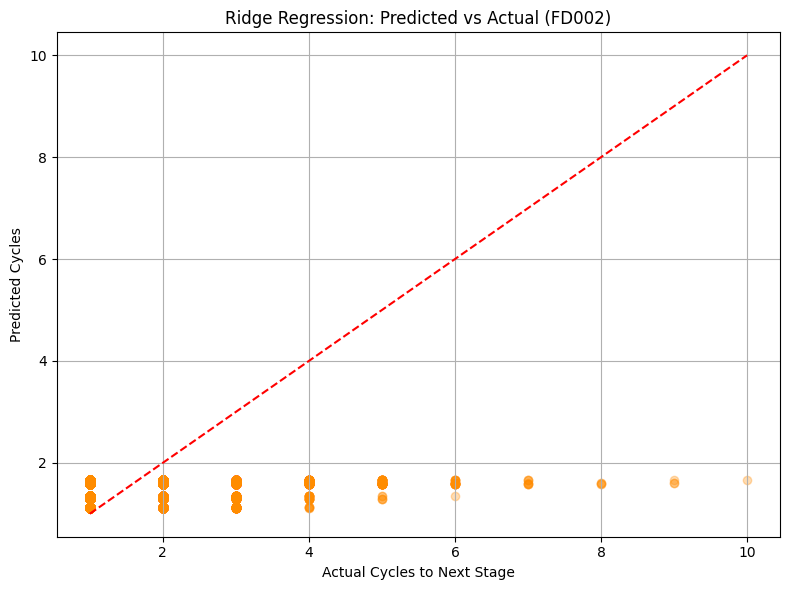

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("Ridge Regression: Predicted vs Actual (FD002)")
plt.grid(True)
plt.tight_layout()

# Save plot
plot_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_pred_vs_actual_fd002.png'))
plt.savefig(plot_path)
print(f"Saved prediction plot to: {plot_path}")
plt.show()

### Step 4E – Save Trained Ridge Model (FD002)
We save the trained model to disk using joblib, so it can be reused or included in ensemble models later.

In [46]:
ridge_model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'ridge_regressor_fd002.pkl'))
joblib.dump(ridge_regressor, ridge_model_path)
print(f"Model saved to: {ridge_model_path}")

Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\ridge_regressor_fd002.pkl


### Step 4F – Plot: Coefficient Magnitudes (FD002)
Ridge Regression is linear, so it exposes feature coefficients instead of feature importances.
We visualize how strongly each sensor impacts the prediction.

Feature coefficient plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_feature_coefficients_fd002.png


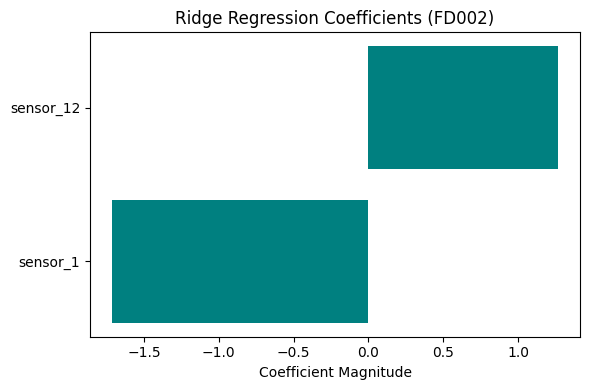

In [47]:
coefs = ridge_regressor.coef_
features = X_train.columns

plt.figure(figsize=(6, 4))
plt.barh(range(len(features)), coefs, align='center', color='teal')
plt.yticks(range(len(features)), features)
plt.xlabel("Coefficient Magnitude")
plt.title("Ridge Regression Coefficients (FD002)")
plt.tight_layout()

# Save plot
coef_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_feature_coefficients_fd002.png'))
plt.savefig(coef_path)
print(f"Feature coefficient plot saved to: {coef_path}")
plt.show()

---
# Step 5 – Support Vector Regression (FD002)

### Step 5A – Import Required Libraries (FD002)
In this step, we import the required SVR regressor along with evaluation and plotting tools.
SVR is effective for small to medium-sized datasets and is robust to outliers due to its margin-based loss.

In [48]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

### Step 5B – Initialize and Train SVR (FD002)
We instantiate the SVR model with an RBF kernel (nonlinear mapping), C=10.0 for margin flexibility, and epsilon=0.2 to allow a tolerance zone in predictions.

In [49]:
# Initialize and Train SVR with StandardScaler (FD002)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

svr_regressor = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=10.0, epsilon=0.2)
)
svr_regressor.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=10.0, epsilon=0.2))])

###  Step 5C – Predict and Evaluate the SVR (FD002)
We use the trained SVR model to predict cycles_to_next_stage and compute regression metrics.

In [50]:
y_pred_svr = svr_regressor.predict(X_test)

rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Evaluation Metrics (FD002):")
print(f" RMSE: {rmse_svr:.2f}")
print(f" MAE : {mae_svr:.2f}")
print(f" R²  : {r2_svr:.4f}")


SVR Evaluation Metrics (FD002):
 RMSE: 0.81
 MAE : 0.47
 R²  : -0.0467


#### Step 5C-1 Cross Validation Evaluation

In [51]:

svr_pipeline = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10.0, epsilon=0.2))

cv_rmse_svr = -cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_svr = -cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_svr = cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='r2')

print("\nCross-Validation Evaluation (SVR – FD002):")
print(f"CV RMSE: {cv_rmse_svr.mean():.2f} ± {cv_rmse_svr.std():.2f}")
print(f"CV MAE : {cv_mae_svr.mean():.2f} ± {cv_mae_svr.std():.2f}")
print(f"CV R²  : {cv_r2_svr.mean():.4f} ± {cv_r2_svr.std():.4f}")



Cross-Validation Evaluation (SVR – FD002):
CV RMSE: 0.81 ± 0.03
CV MAE : 0.48 ± 0.01
CV R²  : -0.0528 ± 0.0044


### Step 5D – Plot: Predicted vs Actual (FD002)
This scatter plot compares SVR predictions with actual values.
Points near the red dashed diagonal line indicate accurate predictions.

Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\svr_pred_vs_actual_fd002.png


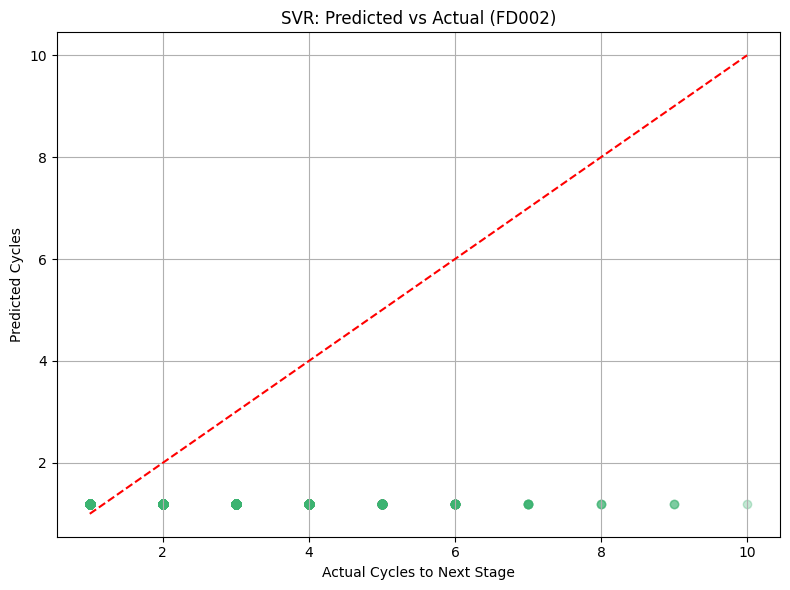

In [52]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.3, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("SVR: Predicted vs Actual (FD002)")
plt.grid(True)
plt.tight_layout()

# Save figure
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'svr_pred_vs_actual_fd002.png'))
plt.savefig(fig_path)
print(f"Saved prediction plot to: {fig_path}")
plt.show()


### Step 5E – Save the Trained SVR Model

In [53]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'svr_regressor_fd002.pkl'))
joblib.dump(svr_regressor, model_path)
print(f"Model saved to: {model_path}")


Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\svr_regressor_fd002.pkl


---
# Step 6 – XGBoost Regressor with Full Evaluation (FD002)

### Step 6A – Import Required Libraries

In [54]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib   
import os


###  Step 6B – Initialize and Train XGBoost Regressor (FD002)
We initialize XGBoost with light regularization to reduce overfitting. The model is trained on the FD002 sensor features (sensor_1, sensor_12).

In [55]:
xgb_regressor = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_regressor.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

###  Step 6C – Predict and Evaluate the XGBoost Model

In [56]:
y_pred_xgb = xgb_regressor.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Evaluation Metrics (FD002):")
print(f" RMSE: {rmse_xgb:.2f}")
print(f" MAE : {mae_xgb:.2f}")
print(f" R²  : {r2_xgb:.4f}")


XGBoost Evaluation Metrics (FD002):
 RMSE: 0.76
 MAE : 0.51
 R²  : 0.0763


#### Step 6C-1 Cross Validation Evaluation

In [57]:

xgb_cv = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

cv_rmse_xgb = -cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_xgb = -cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_xgb = cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='r2')

print("\nCross-Validation Evaluation (XGBoost – FD002):")
print(f"CV RMSE: {cv_rmse_xgb.mean():.2f} ± {cv_rmse_xgb.std():.2f}")
print(f"CV MAE : {cv_mae_xgb.mean():.2f} ± {cv_mae_xgb.std():.2f}")
print(f"CV R²  : {cv_r2_xgb.mean():.4f} ± {cv_r2_xgb.std():.4f}")



Cross-Validation Evaluation (XGBoost – FD002):
CV RMSE: 0.75 ± 0.03
CV MAE : 0.51 ± 0.01
CV R²  : 0.0787 ± 0.0033


### Step 6D – Plot: Predicted vs Actual (FD002)


Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_pred_vs_actual_fd002.png


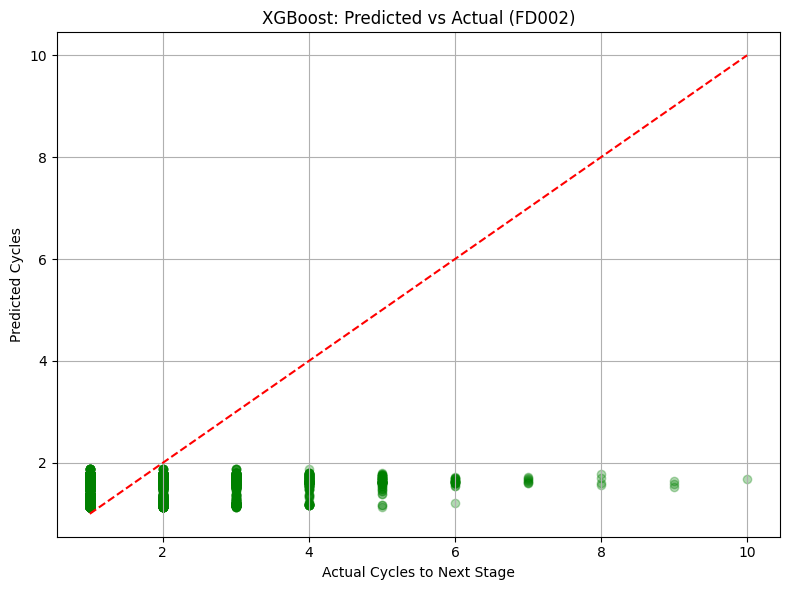

In [58]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("XGBoost: Predicted vs Actual (FD002)")
plt.grid(True)
plt.tight_layout()

# Save figure
xgb_fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_pred_vs_actual_fd002.png'))
plt.savefig(xgb_fig_path)
print(f"Saved prediction plot to: {xgb_fig_path}")
plt.show()


### Step 6E – Save the Trained XGBoost Model

In [59]:
xgb_model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'xgb_regressor_fd002.pkl'))
joblib.dump(xgb_regressor, xgb_model_path)
print(f"Model saved to: {xgb_model_path}")


Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\xgb_regressor_fd002.pkl


### Step 6F – Plot: XGBoost Feature Importances (FD002)

Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_feature_importance_fd002.png


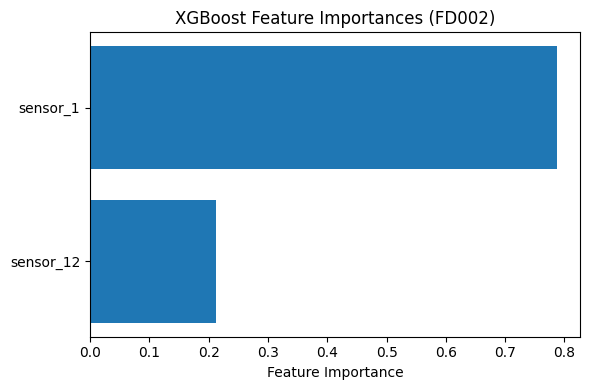

In [60]:
importances = xgb_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(X_train.columns)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(X_train.columns)), [X_train.columns[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importances (FD002)")
plt.tight_layout()

# Save figure
xgb_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_feature_importance_fd002.png'))
plt.savefig(xgb_imp_path)
print(f"Feature importance plot saved to: {xgb_imp_path}")
plt.show()


---
# Step 7 – Final Model Comparison (FD002)

### Step 7A: Define Model Results

In [74]:
# Step 7A: Define Model Results – Updated CV Metrics for FD002
import pandas as pd
import os

model_results_fd002 = pd.DataFrame({
    'Model': [
        'Random Forest (Tuned)',
        'Ridge Regression',
        'Support Vector Regressor',
        'XGBoost Regressor'
    ],
    'RMSE': [0.76, 0.76, 0.81, 0.75],
    'MAE':  [0.51, 0.52, 0.48, 0.51],
    'R² Score': [0.0766, 0.0708, -0.0528, 0.0787]
}).sort_values(by='RMSE').reset_index(drop=True)

# Save CSV
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
os.makedirs(report_dir, exist_ok=True)
cv_path = os.path.join(report_dir, 'model_comparison_cv_fd002.csv')
model_results_fd002.to_csv(cv_path, index=False)

print(" Model comparison table saved to:")
print(cv_path)
print(model_results_fd002)


 Model comparison table saved to:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\model_comparison_cv_fd002.csv
                      Model  RMSE   MAE  R² Score
0         XGBoost Regressor  0.75  0.51    0.0787
1     Random Forest (Tuned)  0.76  0.51    0.0766
2          Ridge Regression  0.76  0.52    0.0708
3  Support Vector Regressor  0.81  0.48   -0.0528


### Step 7B – Plot Comparison Bar Chart (FD002)

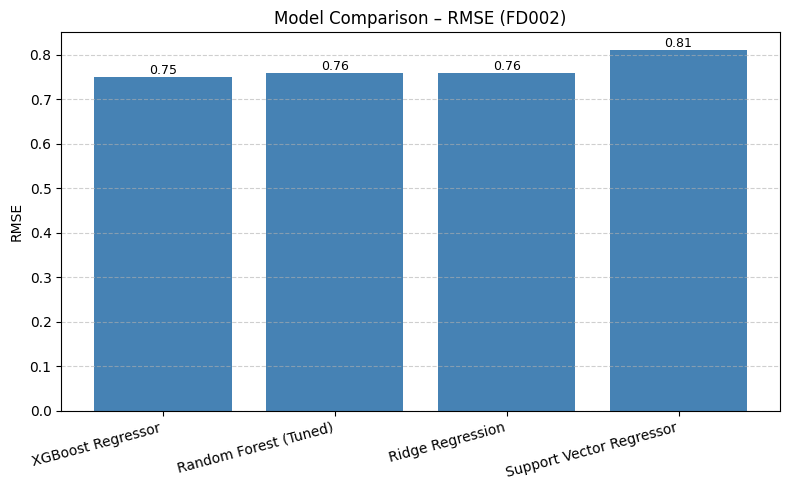

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar(model_results_fd002['Model'], model_results_fd002['RMSE'], color='steelblue')
plt.title("Model Comparison – RMSE (FD002)")
plt.ylabel("RMSE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../../figures/phase4/model_comparison_rmse_fd002.png')
plt.show()


### Step 7C – MAE and R² Score Plots

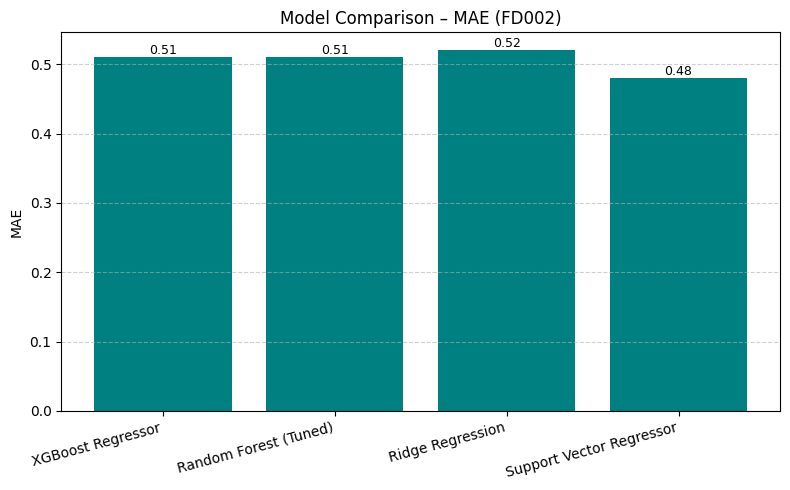

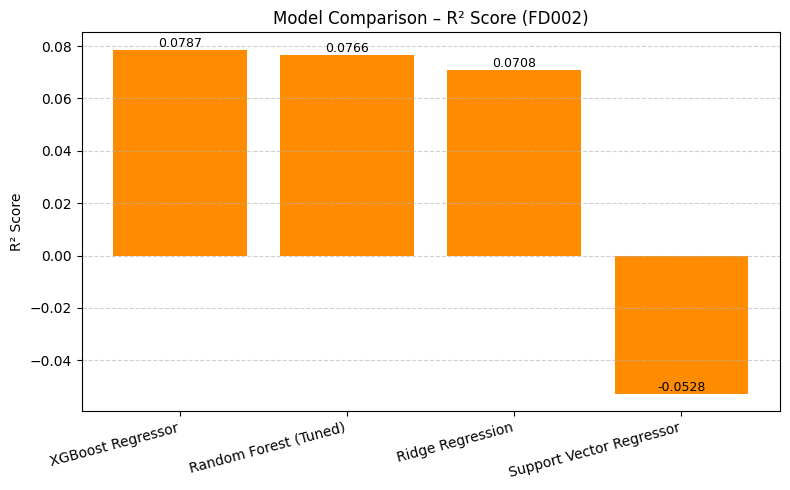

In [76]:
# MAE Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results_fd002['Model'], model_results_fd002['MAE'], color='teal')
plt.title("Model Comparison – MAE (FD002)")
plt.ylabel("MAE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../../figures/phase4/mae_comparison_fd002.png')
plt.show()

# R² Score Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results_fd002['Model'], model_results_fd002['R² Score'], color='darkorange')
plt.title("Model Comparison – R² Score (FD002)")
plt.ylabel("R² Score")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.4f}', (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../../figures/phase4/r2_comparison_fd002.png')
plt.show()


---
# Step 8 – Residual Analysis – Ensemble and Individual Models (FD002)

### Step 8A: Import Required Libraries

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

### Step 8B: Compute Residuals for All Models

In [64]:
# Residual = Actual - Predicted
residuals = {
    "Random Forest": y_test - y_pred_rf,
    "Ridge Regression": y_test - y_pred_ridge,
    "SVR": y_test - y_pred_svr,
    "XGBoost": y_test - y_pred_xgb
}


### Step 8C: Plot Residuals Distribution

Saved residual distribution plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_fd002.png


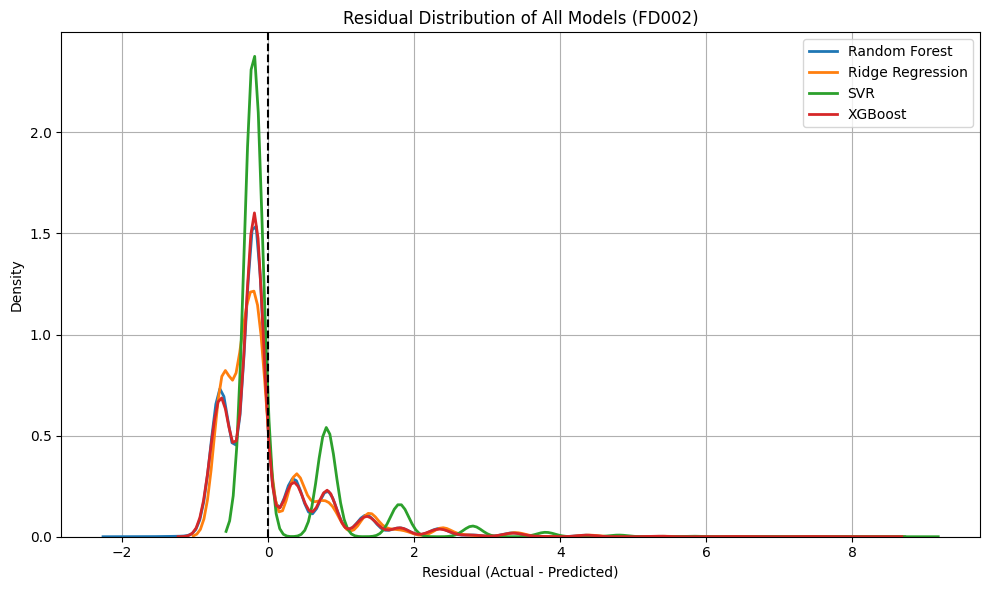

In [65]:
plt.figure(figsize=(10, 6))
for name, res in residuals.items():
    sns.kdeplot(res, label=name, linewidth=2)

plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution of All Models (FD002)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_distribution_fd002.png'))
plt.savefig(fig_path)
print(f"Saved residual distribution plot to: {fig_path}")
plt.show()


### Step 8D: Residuals vs Predicted Plot for Key Models

Saved residual vs predicted plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_fd002.png


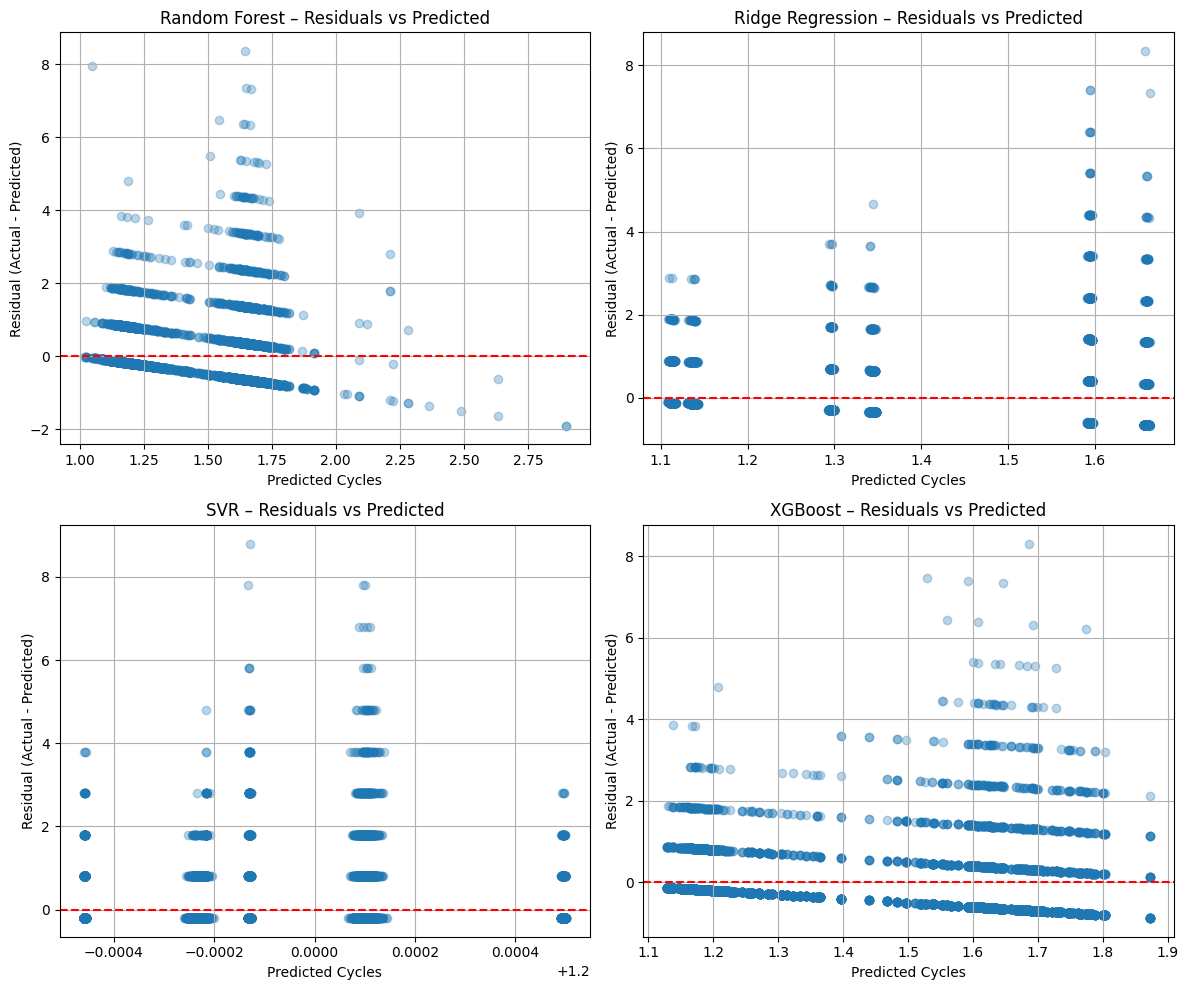

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
model_preds = {
    "Random Forest": y_pred_rf,
    "Ridge Regression": y_pred_ridge,
    "SVR": y_pred_svr,
    "XGBoost": y_pred_xgb
}

for ax, (name, pred) in zip(axes.flatten(), model_preds.items()):
    ax.scatter(pred, residuals[name], alpha=0.3)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f"{name} – Residuals vs Predicted")
    ax.set_xlabel("Predicted Cycles")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.grid(True)

plt.tight_layout()
fig_path2 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_vs_predicted_fd002.png'))
plt.savefig(fig_path2)
print(f"Saved residual vs predicted plot to: {fig_path2}")
plt.show()


---
# Step 9 – Ensemble Averaging for FD002

### Step 9A – Import Required Libraries (FD002)

In [67]:
# Step 9A – Import Required Libraries (FD002)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

### Step 9 – Weighted Ensemble Averaging (FD002)

In [77]:
# Step 9: Weighted Ensemble Averaging (FD002)
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse_vals = {
    'rf': 0.76,
    'ridge': 0.76,
    'svr': 0.81,
    'xgb': 0.75
}

# Compute weights
inv_rmse = {k: 1/v for k, v in rmse_vals.items()}
total_inv = sum(inv_rmse.values())
weights = {k: v/total_inv for k, v in inv_rmse.items()}

print(" Model Weights (Inverse RMSE):")
for k, v in weights.items():
    print(f"{k.upper()} weight: {v:.4f}")

# Weighted prediction
y_pred_weighted_fd002 = (
    weights['rf'] * y_pred_rf +
    weights['ridge'] * y_pred_ridge +
    weights['svr'] * y_pred_svr +
    weights['xgb'] * y_pred_xgb
)

# Evaluate
rmse_wt = np.sqrt(mean_squared_error(y_test, y_pred_weighted_fd002))
mae_wt = mean_absolute_error(y_test, y_pred_weighted_fd002)
r2_wt = r2_score(y_test, y_pred_weighted_fd002)

print("\n Weighted Ensemble Evaluation (FD002):")
print(f"RMSE: {rmse_wt:.4f}")
print(f"MAE : {mae_wt:.4f}")
print(f"R²  : {r2_wt:.4f}")


 Model Weights (Inverse RMSE):
RF weight: 0.2531
RIDGE weight: 0.2531
SVR weight: 0.2374
XGB weight: 0.2564

 Weighted Ensemble Evaluation (FD002):
RMSE: 0.7653
MAE : 0.5020
R²  : 0.0714


### Step 9C – Evaluate Ensemble Performance (FD002)

In [69]:
# Step 9C – Evaluate Ensemble Performance (FD002)

rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
mae_ens = mean_absolute_error(y_test, y_pred_ensemble)
r2_ens = r2_score(y_test, y_pred_ensemble)

print("Ensemble Averaging Evaluation (FD002):")
print(f" RMSE: {rmse_ens:.2f}")
print(f" MAE : {mae_ens:.2f}")
print(f" R²  : {r2_ens:.4f}")


Ensemble Averaging Evaluation (FD002):
 RMSE: 0.77
 MAE : 0.50
 R²  : 0.0707


### Step 9D – Visualization: Predicted vs Actual (FD002)

Saved ensemble prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ensemble_pred_vs_actual_fd002.png


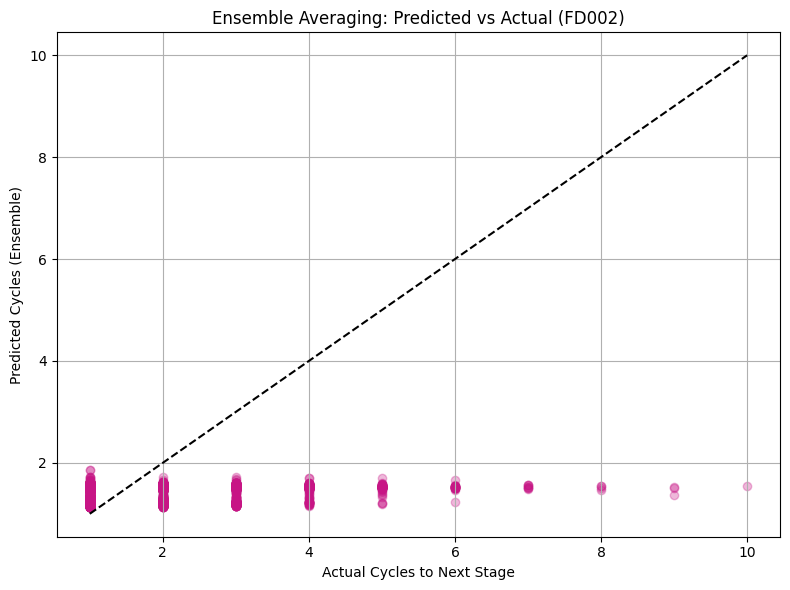

In [70]:
# Step 9D – Visualization: Predicted vs Actual (FD002)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ensemble, alpha=0.3, color='mediumvioletred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles (Ensemble)")
plt.title("Ensemble Averaging: Predicted vs Actual (FD002)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ensemble_pred_vs_actual_fd002.png'))
plt.savefig(fig_path)
print(f"Saved ensemble prediction plot to: {fig_path}")
plt.show()


### Step 9E – Add Ensemble to Table

In [78]:
# Step 9E: Add Ensemble to Table – FD002
ensemble_row = pd.DataFrame({
    'Model': ['Weighted Ensemble (Inv RMSE)'],
    'RMSE': [rmse_wt],
    'MAE': [mae_wt],
    'R² Score': [r2_wt]
})

model_results_fd002 = pd.concat([model_results_fd002, ensemble_row], ignore_index=True)
model_results_fd002 = model_results_fd002.sort_values(by='RMSE').reset_index(drop=True)

# Save updated table
ensemble_path = os.path.join(report_dir, 'model_comparison_cv_with_ensemble_fd002.csv')
model_results_fd002.to_csv(ensemble_path, index=False)

print(f"\n Final model comparison with ensemble saved to:\n{ensemble_path}")



 Final model comparison with ensemble saved to:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\model_comparison_cv_with_ensemble_fd002.csv


---
# Step 10 – Residual Analysis for Ensemble Averaging (FD002)

### Step 10A: Residual Distribution Plot – Ensemble Averaging

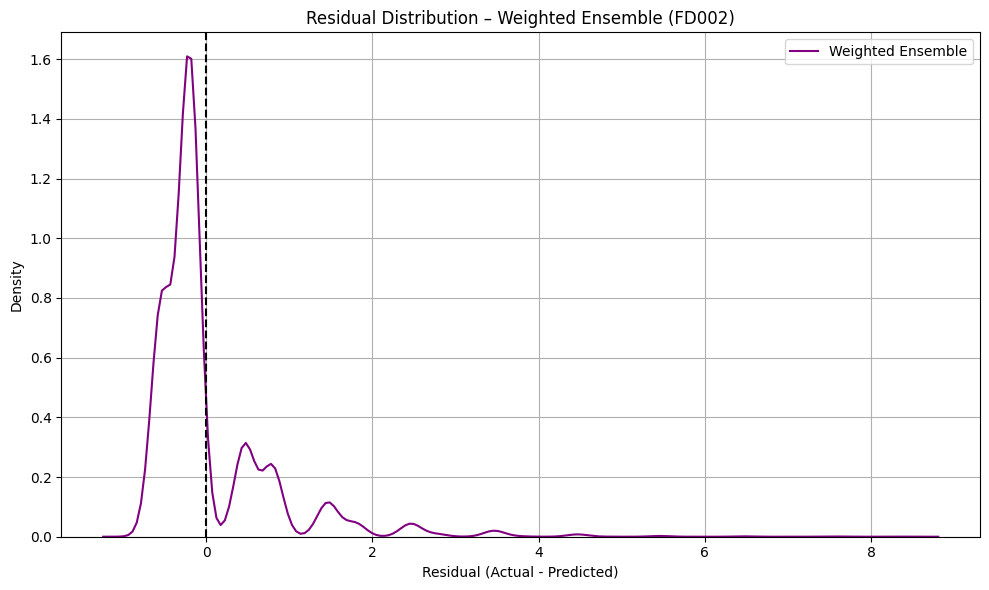

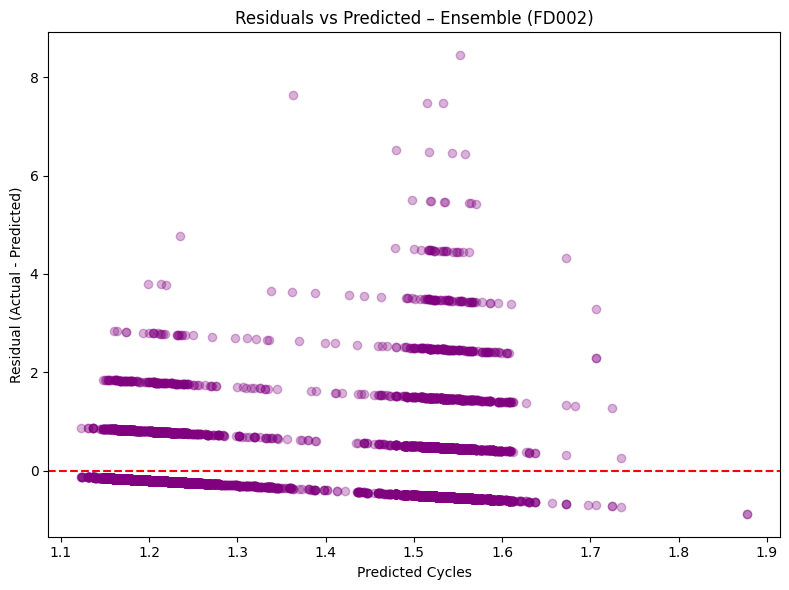

In [79]:
# Step 10A – Residual Distribution (FD002)
import seaborn as sns
import matplotlib.pyplot as plt

residuals_weighted = y_test - y_pred_weighted_fd002

plt.figure(figsize=(10, 6))
sns.kdeplot(residuals_weighted, label="Weighted Ensemble", color='purple')
plt.axvline(0, linestyle='--', color='black')
plt.title("Residual Distribution – Weighted Ensemble (FD002)")
plt.xlabel("Residual (Actual - Predicted)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('../../figures/phase4/residual_distribution_weighted_ensemble_fd002.png')
plt.show()

# Step 10B – Residuals vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_weighted_fd002, residuals_weighted, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Cycles")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted – Ensemble (FD002)")
plt.tight_layout()
plt.savefig('../../figures/phase4/residual_vs_predicted_weighted_ensemble_fd002.png')
plt.show()


---
# FD002 – Save Final Predictions + Ensemble Outputs

In [80]:
import os
import pandas as pd

# Set correct save path
save_path_fd002 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
os.makedirs(save_path_fd002, exist_ok=True)

# Construct DataFrame with all outputs
final_df_fd002 = pd.DataFrame({
    'unit': test_df['unit'],
    'time': test_df['time'],
    'actual_cycles_to_next_stage': y_test,
    'random_forest_prediction': y_pred_rf,
    'ridge_prediction': y_pred_ridge,
    'svr_prediction': y_pred_svr,
    'xgboost_prediction': y_pred_xgb,
    'weighted_ensemble_prediction': y_pred_weighted_fd002
})

# Save to CSV
fd002_csv_path = os.path.join(save_path_fd002, 'final_predictions_fd002.csv')
final_df_fd002.to_csv(fd002_csv_path, index=False)

print(f" FD002 predictions saved to: {fd002_csv_path}")


 FD002 predictions saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\final_predictions_fd002.csv
